# Batsman Parallel Performance Eval Agent

### Necesarry imports --------------------

In [142]:
from langgraph.graph import StateGraph ,START , END
from langchain_mistralai import ChatMistralAI
from typing import TypedDict
from dotenv import load_dotenv

In [143]:
load_dotenv()
model = ChatMistralAI(model_name="ministral-3b-latest", temperature=0.7)

In [ ]:
class Batsman(TypedDict):
    runs: int
    balls: int
    fours: int
    sixes: int
    sr: float
    bpb: float
    rbb: float
    summary: str

In [145]:
def calculate_sr(state:Batsman):
    sr = (state['runs']/state['balls'])*100
    return {'sr' :sr}

In [146]:
def calculate_bpb(state:Batsman):
    bpb = state['balls']/(state['fours']+state['sixes'])
    return {'bpb' : bpb}

In [147]:
def Runs_by_boundary(state:Batsman):
    rbb = ((state['fours']*4) + (state['sixes']*6))/state['runs']
    return {'rbb' : rbb}
    

In [148]:
def summary(state: Batsman) -> dict:
    prompt = f"""
    You are an expert cricket analyst. Evaluate the following batsman's performance based on the calculated metrics:

    - Runs Scored: {state['runs']}
    - Balls Faced: {state['balls']}
    - Fours: {state['fours']}
    - Sixes: {state['sixes']}
    - Strike Rate: {state['sr']:.2f}
    - Balls per Boundary: {state['bpb']:.2f}
    - Boundary Run Share: {state['rbb'] * 100:.1f}%

    Provide a concise performance evaluation covering their scoring intent, boundary-hitting effectiveness, and overall match impact.
    """
    
    response = model.invoke(prompt)
    return {'summary': response.content}

In [149]:
graph = StateGraph(Batsman) 

graph.add_node('Strike_rate' , calculate_sr)
graph.add_node('Balls_per_boundary', calculate_bpb)
graph.add_node('Runs_by_boundary' , Runs_by_boundary)
graph.add_node('summary' , summary)

#edges

graph.add_edge( START , 'Strike_rate')
graph.add_edge( START , 'Balls_per_boundary')
graph.add_edge( START , 'Runs_by_boundary')

#merging
graph.add_edge(
    ['Strike_rate', 'Balls_per_boundary', 'Runs_by_boundary'], 
    'summary'
)

graph.add_edge('summary' ,END )

workflow = graph.compile()




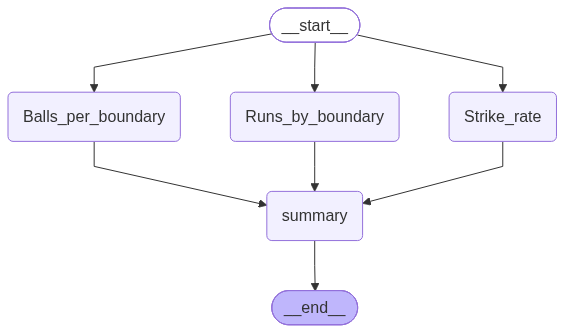

In [150]:
workflow

In [153]:
initial_state = {
     'runs' :100,
     'balls': 50,
     'fours': 6,
     'sixes': 4
}

result = workflow.invoke(initial_state)

In [155]:
print(result['summary'])

Here’s a concise performance evaluation of the batsman’s **100-run innings (50 balls, 6 fours, 4 sixes, 200 SR, 48% boundary share)**:

### **Scoring Intent & Technique**
- **High Strike Rate (200+)** suggests aggressive yet efficient play—likely a **lower-order finisher** or a **middle-order batsman** who accelerates late in the innings. The **balls per boundary (5)** indicate **precision over power**, with deliberate timing rather than pure power-hitting.
- **Boundary Run Share (48%)** is excellent, implying **consistent scoring from boundaries**—likely a **right-handed batsman** (right-handed batters often hit more fours/sixes) who balances **stroke play with boundary drives**.
- **Runs per ball (2)** is solid but not outstanding, suggesting **efficient use of resources** rather than explosive scoring.

### **Boundary-Hitting Effectiveness**
- **4 fours (12 runs) + 4 sixes (24 runs) = 36 runs from boundaries (36%)**, with the remaining **64% from dot balls, singles, and twos**—a **b